## Change in Vegetation Acreage V.S Tides Analysis using GEE API

The purpose of this notebook is to conduct a time series analysis of the change in vegetation acreage in Long Island NY's south bay from 1995 - 2025 to investigate decreases in wetland vegetation overtime. This notebook investigates the outliers in the resulting time series analysis data and assess the effect of tides on wetland vegetation acreage over time. 

This notebook will walkthrough the following steps:

1. Import GEE project data
2. Visualize the study area and asset data
3. Import image collections Landsat 5 and Landsat 8 and filter images by location and time of year to create a new image collection
4. Use NDVI to calculate vegetation acreage in Long Island south bay
5. Use NOAA's Tide prediction API to get tide hight data
6. Merge vegetation data with tide predictions
7. Conduct exploratory analysis to understand the distribution of the vegetation acreage data
8. Plot vegetation acreage and tide prediction data into two different interactive time series charts with one chart visualizing flagged data. 


In [171]:
# Import libraries 

import ee
import geemap
import pandas as pd
import requests
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
pio.renderers.default = 'notebook_connected'



In [172]:
# To run this notebook you need a Google Earth Engine account
# Note: If you are not using a jupyter environment you can also run ee.Authenticate() in your terminal to connect to your project.

ee.Authenticate(auth_mode='gcloud'); 

In [ ]:
# Initialize GEE using credentials from command line authentication

ee.Initialize(project='Your own GEE project ID') 

print(ee.String('GEE connection successful!').getInfo());

In [ ]:
#check what assests you have in your project
assets = ee.data.listAssets('projects/Your own GEE project ID/assets') 
for asset in assets['assets']:
    print(asset['id'])

Visualize The Study Area, Wetland Geometry and NOAA Tide Gauge Location.

In [175]:
# Create a map centered on Great South Bay
Map = geemap.Map(center=[40.65, -73.2], 
zoom=10, 
lite_mode=True  # disables toolbar widgets that require live kernel
)


# Add the wetlands geometry as a layer
wetlands_layer = ee.FeatureCollection(
    'projects/Your own GEE project ID/assets/Clip_WReg_to_JBGSB_Shape_reproj'
)

# Style the wetlands geometry
wetlands_style = {
    'color': '1d6b99',      # blue outline
    'fillColor': '1d6b9950', # semi transparent blue fill
    'width': 2
}

# Simplified version for comparison
simplified_fc = wetlands_layer.map(
    lambda f: f.simplify(maxError=100)
)

# Style the simplified wetlands geometry
simplified_wetlands_style = {
    'color': '#FFFF00',      # yellow outline
    'fillColor': 'FFFF0050', # semi transparent yellow fill
    'width': 2
}

# Add The Battery tide gauge location as a point
battery_point = ee.Geometry.Point([-74.0142, 40.7006])
battery_feature = ee.FeatureCollection([
    ee.Feature(battery_point, {'name': 'The Battery (NOAA 8518750)'})
])

# Style the tide gauge point
gauge_style = {
    'color': 'd73027',   # red
    'pointSize': 15,
    'width': 2
}

# Switch to Google Maps basemap which doesn't have this restriction
Map.add_basemap('HYBRID')  # Google satellite with labels


# Add layers to the map
Map.addLayer(simplified_fc, simplified_wetlands_style,'Study Area — Simplified Boundary (100m)')
Map.addLayer(wetlands_layer, wetlands_style, 'Study Area — Great South Bay Wetlands')
Map.addLayer(battery_feature, gauge_style, 'The Battery — NOAA Tide Gauge')

# Add an interactive legend
Map.add_legend(
    title='Map Legend',
    legend_dict={
        'Study Area Wetlands': '1d6b99',
        'Study Area Wetlands Simplified': '#FFFF00',
        'NOAA Tide Gauge — The Battery': 'd73027'
    }
)


# Display the map
Map;

Click on the image below to interact with the map!

[![Study Area Map](Saltmarsh_Study_Area.jpg)](https://polanch190.github.io/GEE-Spatial-Temporal-Analysis-of-Changes-in-Marsh-Vegetation-Density-/SaltMarsh_StudyArea.html)


Next we will be creating a filtered image collection. First let's load Landsat 5 and Landsat 8 satellite image data then filter the images by location and month to avoid phenological changes. Here we use jBayPoint and the [NYSDEC Regulatory Tidal Wetland](https://data.gis.ny.gov/datasets/661acb5eaffb4be39b0d6d2203e636c3_1/explore?location=40.707620%2C-73.314647%2C11) geometry to filter for  images precisely in our study area.  

In [ ]:
jBayPoint = ee.Geometry.Point([-73.756, 40.616])

# Full precision geometry for reduceRegion acreage calculation
WetlandsGeom = ee.FeatureCollection(
    'projects/Your own GEE project ID/assets/Clip_WReg_to_JBGSB_Shape_reproj'
).geometry()

# Simplified geometry ONLY for filterBounds — just needs to find overlapping scenes
# Does not affect acreage calculation accuracy latter on where we will use the detailed geometry.
WetlandsGeomSimple = WetlandsGeom.simplify(maxError=500)

# Load and filter Landsat 8 - August only
L8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filter(ee.Filter.calendarRange(2013, 2025, 'year')) \
    .filter(ee.Filter.calendarRange(8, 8, 'month')) \
    .filterBounds(jBayPoint) \
    .filterBounds(WetlandsGeomSimple)  # simplified for filtering only

# Load and filter Landsat 5 - August only
L5 = ee.ImageCollection('LANDSAT/LT05/C02/T1_L2') \
    .filter(ee.Filter.calendarRange(1995, 2012, 'year')) \
    .filter(ee.Filter.calendarRange(8, 8, 'month')) \
    .filterBounds(jBayPoint) \
    .filterBounds(WetlandsGeomSimple)  # simplified for filtering only

print('L8 image count:', L8.size().getInfo())
print('L5 image count:', L5.size().getInfo())

Now that we have collected and filtered our data we will create the functions to calculate NDVI for Landsat 5 and Landsat 8. For this step, remember to check the metadata of the satellite data you are using as band names may differ by image collection. NDVI is calculated using the specific properties of red light absorption and near-infrared (NIR) light reflection by vegetation, so you will need to know which is the red band and the NIR band in your data collection. Here you see that to calculate NDVI for Landsat 8 we need bands 'SR_B5'and 'SR_B4' while Landsat 5 uses 'SR_B4', 'SR_B3'. After NDVI is calculated, we will merege the data into one new image collection.

In [ ]:

# Function to calculate NDVI for Landsat 8
def add_ndvi_L8(image):
    ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    return image.addBands(ndvi)

# Function to calculate NDVI for Landsat 5
def add_ndvi_L5(image):
    ndvi = image.normalizedDifference(['SR_B4', 'SR_B3']).rename('NDVI')
    return image.addBands(ndvi)

# Add NDVI bands to existing collections
L8 = L8.map(add_ndvi_L8)
L5 = L5.map(add_ndvi_L5)

# Merge the two collections
QLIL8_5merge = L8.merge(L5)

print('Total images:', QLIL8_5merge.size().getInfo())

Since the NYSDEC Regulatory Tidal Wetland geometry is large we will first test our function on one image and view the properties using .getinfo to see if we successfully calculated the acreage of that image. 

In [ ]:
# Test calculate_area on a single image before running all 90
test_image = ee.Image(QLIL8_5merge.first())
test_result = calculate_area(test_image)
print(test_result.getInfo())

Success! Now lets write a function that loops over every image in our image collection.

In [ ]:
# Function to calculate vegetated area for a single image
def calculate_area(image):
    
    # Get the acquisition date and time of the image (converted from UTC to Eastern Time) 
    # as a formatted string for use later when we export the feature below to table. 
    # remember that having this table is important for tide calculation later too.

    date = image.date().format('YYYY-MM-dd HH:mm:ss', 'America/New_York')
    
    # Select the NDVI band and apply the 0.2 threshold — pixels >= 0.2 are vegetated (value 1)
    # selfMask() removes non-vegetated pixels (value 0) so they don't contribute to the sum
    # multiply(ee.Image.pixelArea()) converts each vegetated pixel to its area in square meters
    # rename('Area') labels the output band as 'Area' instead of 'NDVI'
    # reduceRegion sums all vegetated pixel areas within WetlandsGeom at 30m resolution
    area = image.select('NDVI').gte(0.2).selfMask() \
        .multiply(ee.Image.pixelArea()).rename('Area') \
        .reduceRegion(
            reducer=ee.Reducer.sum(),  # adds up all vegetated pixel areas in square meters
            geometry=WetlandsGeom,     # your Great South Bay wetlands boundary
            scale=30,                  # Landsat pixel size in meters
            maxPixels=1e9              # allows up to 1 billion pixels to prevent timeout
        )
    
    # Convert total area from square meters to acres by dividing by 4046.86
    acres = ee.Number(area.get('Area')).divide(4046.86)
    
    # Package the date and acreage into a Feature so results can be 
    # exported as a table — one row per image
    return ee.Feature(None, {
        'date': date,                                        # image acquisition date and time
        'acres': acres,                                      # vegetated area in acres
        'system:time_start': image.get('system:time_start') # raw timestamp for sorting later
    })

# Apply the calculate_area function to every image in the merged collection
# This runs the calculation 90 times — once per image — instead of once per year composite
area_per_image = QLIL8_5merge.map(calculate_area)


#Confirm 90 features were created — one per image
# Export to Google Drive using batch system instead of getInfo()
# Batch export is used here because the complex Clip_WReg_to_JBGSB geometry
# makes per-image reduceRegion too heavy for the interactive environment
export_task = ee.batch.Export.table.toDrive(
    collection=area_per_image,
    description='VegetatedArea_PerImage_1995_2025',
    folder='Wetland project NDVI data',
    fileNamePrefix='VegetatedArea_PerImage_1995_2025',
    fileFormat='CSV',
    selectors=['date', 'acres']  # only export columns we need
)

export_task.start()
print('Export started! Check Google Drive when task is completed in GEE.') 




# Note: If your project area's geometry contains fewer vertices than you dont have to export to drive. You can instead skip the export, 
# print('Features calculated:', area_per_image.size().getInfo())
# and the run the following commented out cell below. 



In [122]:
# # Convert the GEE FeatureCollection to a pandas dataframe directly if your geometry is less detailed and do the following otherwise export to drive as shown in the above cell.

# # getInfo() pulls all the data from GEE into Python memory
# features = area_per_image.getInfo()['features']

# # Extract the properties from each feature into a list of dictionaries. Don't forget, the f before properties is the f in features.
# data = [f['properties'] for f in features]

# # Convert to pandas dataframe
# df_area_per_image = pd.DataFrame(data)

# # Drop the system:time_start column since we have the readable date already
# df_area_per_image = df_area_per_image.drop(columns=['system:time_start'])

# # Sort by date chronologically
# df_area_per_image = df_area_per_image.sort_values('date').reset_index(drop=True)

# print(f'Total rows: {len(df_area_per_image)}')
# df_area_per_image.head(10)
# df_area_per_image.to_csv("VegetatedArea_per_Image95_25.csv", index=False) # recall that: index=false is so that there isn't a index column in the csv with no column name. This column isn't necessary.


After your data is successfully exported to your drive, read the csv in and continue with data cleaning and exploratory data analysis.

In [176]:

VegetatedArea_PerImage_1995_2025_DEC = pd.read_csv('VegetatedArea_PerImage_1995_2025.csv')

Print the number of rows to make sure the length of the dataset is the same as our QLIL8_5merge image collection. Sort the data and check the first 10 rows of the data.

In [177]:
print(f'Total rows: {len(VegetatedArea_PerImage_1995_2025_DEC)}')
VegetatedArea_PerImage_1995_2025_DEC = VegetatedArea_PerImage_1995_2025_DEC.sort_values('date').reset_index(drop=True)
VegetatedArea_PerImage_1995_2025_DEC.head(10)
#Next you will be doing data cleaning.

Total rows: 90


,date,acres
0,1995-08-12 10:37:14,2320.706056
1,1995-08-28 10:36:29,4606.331829
2,1996-08-05 10:55:24,5065.570960
3,1996-08-21 10:56:13,0.000000
4,1996-08-30 10:50:32,3395.817988
5,1997-08-17 11:05:15,8886.693514
6,1997-08-24 11:11:38,3129.265937
7,1998-08-20 11:12:12,9888.478025
8,1998-08-27 11:18:29,0.344665
9,1999-08-23 11:11:08,8971.117680


Notice that the output table has some acreage values that are below 0 in some years which are suspiciously low. Rows 3 and 8 show 0.000000 and 0.445011 acres for 1996-08-21 and 1998-08-27. It is not likely that all the wetland vegetation in Long Island's south bay disappeared in these years and suddenly reappeared in the following years. Therefore, these maybe caused by cloud cover or other image quality issues suppressing NDVI below 0.2 across almost the entire wetlands area for those images. We will first investigate the data by examining the distribution, flag the lowest values and then clean up the data to remove the 0/ near 0 values and prevent certain images from incorrectly dragging down the annual acreage. 

count       90.000000
mean      2983.679479
std       2811.568495
min          0.000000
25%        734.020755
50%       2176.085117
75%       4720.890089
max      10024.194437
Name: acres, dtype: float64


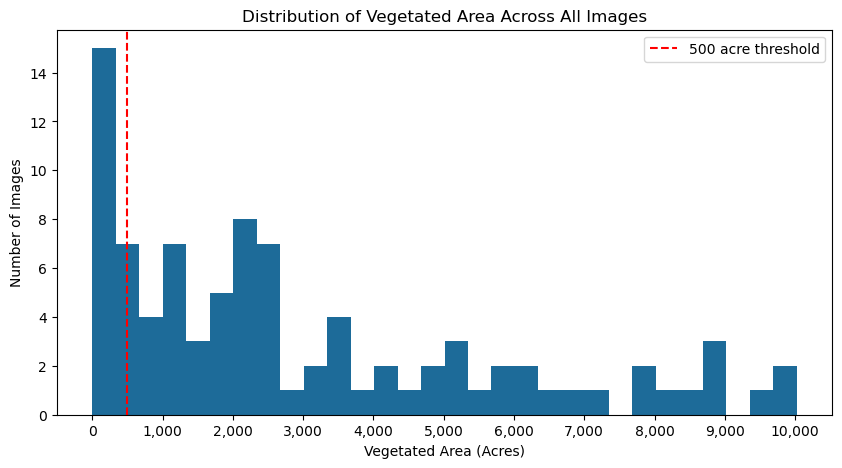

In [178]:
# Examine the distribution of the acreage data
print(VegetatedArea_PerImage_1995_2025_DEC['acres'].describe())

# Plot a histogram to visualize the distribution
plt.figure(figsize=(10, 5))
plt.hist(VegetatedArea_PerImage_1995_2025_DEC['acres'], bins=30, color='#1d6b99')
plt.xlabel('Vegetated Area (Acres)')
plt.ylabel('Number of Images')
plt.title('Distribution of Vegetated Area Across All Images')
plt.axvline(x=500, color='red', linestyle='--', label='500 acre threshold')

# Set x axis ticks at every 1000 acres for clearer reading
plt.xticks(range(0, 11000, 1000))

# Add comma formatting to x axis values e.g. 1000 becomes 1,000
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))


plt.legend()
plt.show()

Explanation of Statistics:

* Min is 0.0 — confirming some images have essentially no detected vegetation.
* Mean is 2,983 acres but median (50%) is 2,176 acres — the mean is pulled up by high outliers.
* Standard deviation is 2,811 — extremely high variability confirming what we saw in the charts.
* 25th percentile is 734 acres — meaning 25% of images show less than 734 acres.

Examining the histogram:

* There appears to be a cluster of about 15 images near 0 that look like outliers.
* There appears to be a natural gap around 500 acres separating that low cluster from the rest of the distribution.
* The bulk of images fall between 1000-4000 acres.

Since, there is a visible gap in the data around 500 acres, we could set a threshold of 500 acres and remove any rows containing acreage values <= to 500>. However, we should first cross reference the tidal data to understand if the outliers are being impacted by the tides. We will export the acreage data to a new dataframe containing a new column flagging the outliers (values <= to 500>). We will call these outliers suspect data points moving forward in this analysis since they are likely due to cloud cover or tidal discrepancies.

In [179]:
# Create a new dataframe with a quality flag column
# keeping the original dataframe intact for reference
df_flagged = VegetatedArea_PerImage_1995_2025_DEC.copy() # Remember, that unlike in R,  we use .copy() in python to avoid modifying the original read in file. 

# Flag images with acreage below 500 acres as suspect
# 500 acres was chosen based on the natural gap visible in the distribution histogram
acreage_threshold = 500

df_flagged['quality_flag'] = df_flagged['acres'].apply(
    lambda x: 'suspect' if x < acreage_threshold else 'good'
)

# Summary of flagged images
print(f'Total images: {len(df_flagged)}')
print(f'Good images: {len(df_flagged[df_flagged["quality_flag"] == "good"])}')
print(f'Suspect images: {len(df_flagged[df_flagged["quality_flag"] == "suspect"])}')
print('\nSuspect images:')
df_flagged[df_flagged['quality_flag'] == 'suspect'][['date', 'acres', 'quality_flag']]

Total images: 90
Good images: 71
Suspect images: 19

Suspect images:


,date,acres,quality_flag
3,1996-08-21 10:56:13,0.000000,suspect
8,1998-08-27 11:18:29,0.344665,suspect
10,1999-08-30 11:17:07,0.000000,suspect
13,2001-08-03 11:20:12,0.000000,suspect
19,2002-08-31 11:07:53,353.297713,suspect
20,2003-08-02 11:10:26,54.125424,suspect
24,2004-08-11 11:22:46,326.311318,suspect
35,2008-08-06 11:26:02,54.130729,suspect
39,2009-08-09 11:29:05,36.678688,suspect
43,2010-08-12 11:30:12,18.238033,suspect


Here we can see that there are 19 images out of 90 with acreage less than or equal to 500 acres which is suspected to be due to either cloud cover or tidal difference. Let's pull in the tide data using NOAA's tide prediction API to evaluate whether our vegetation acreage time series analysis is being impacted by tides or cloud cover.  

In [180]:

def get_tides_for_date(date_str):
    """
    Fetches hi/lo tide predictions for a given date from 
    The Battery, Manhattan — NOAA Station ID: 8518750
    
    Parameters:
        date_str: date in 'YYYYMMDD' format e.g. '19950812'
    
    Returns:
        pandas DataFrame with columns: t (time), v (tide height ft), type (H or L)
        Returns empty DataFrame if no data found for that date
    
    Note: Tide predictions are used rather than observed water levels
    because predictions provide consistent data coverage across the 
    full 1995-2025 study period without gaps. Observed water level 
    data will be explored in future analysis to capture storm surge effects.
    """
    url = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
    
    params = {
        'begin_date': date_str,   # start date of query
        'end_date': date_str,     # same as begin_date — one day at a time
        'station': '8518750',     # The Battery, Manhattan
        'product': 'predictions', # predicted tides not observed
        'datum': 'MLLW',          # Mean Lower Low Water — standard tide datum
        'time_zone': 'lst_ldt',   # Eastern Time including daylight savings
        'interval': 'hilo',       # high and low tide peaks only
        'units': 'english',       # feet not metric
        'application': 'web_services',
        'format': 'json'          # return as JSON
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    if 'predictions' in data:
        return pd.DataFrame(data['predictions'])
    else:
        print(f"No data for {date_str}: {data}")
        return pd.DataFrame()

In [181]:
# Loop through every image in df_flagged and match to nearest tide prediction. 
# Note: Use df_area_per_image if you didn't have to go the route of exporting your acreage data and went directly to pandas dataframe.

results = []

for _, row in df_flagged.iterrows():
    
    # Convert the date string to a datetime object for time comparison
    image_dt = pd.to_datetime(row['date'])
    
    # Format the date as 'YYYYMMDD' for the NOAA API
    date_str = image_dt.strftime('%Y%m%d')
    
    # Get all hi/lo tide peaks for that day from The Battery
    tides = get_tides_for_date(date_str)
    
    if tides.empty:  # if no tide data returned for this date
        results.append({
            'date': row['date'],
            'acres': row['acres'],
            'nearest_tide_time': None,
            'tide_height_ft': None,
            'tide_type': None,
            'hours_from_tide': None,
            'data_source': 'predicted'
        })
        continue  # skip to the next image
    
    # Convert tide times to datetime for comparison
    tides['datetime'] = pd.to_datetime(tides['t'])
    
    # Calculate time difference between image and each tide peak
    tides['time_diff'] = abs(tides['datetime'] - image_dt)
    
    # Find the tide peak closest in time to the image acquisition
    nearest = tides.loc[tides['time_diff'].idxmin()] # returns the INDEX of the smallest time difference. Recall .loc[] stands for location — it's pandas' way of selecting a row by its index label.
    
    # Calculate hours between image and nearest tide peak
    hours_from_tide = nearest['time_diff'].total_seconds() / 3600
    
    results.append({
        'date': row['date'],                           # image date and time
        'acres': row['acres'],                         # vegetated area in acres
        'quality_flag': row['quality_flag'],           # flagged data with acres <= to 500 
        'nearest_tide_time': nearest['t'],             # time of nearest tide peak
        'tide_height_ft': float(nearest['v']),         # tide height in feet
        'tide_type': nearest['type'],                  # H or L
        'hours_from_tide': round(hours_from_tide, 2), # hours from nearest tide peak
        'data_source': 'predicted'                     # predicted vs observed
    })

# Convert results to dataframe
df_final = pd.DataFrame(results)

No data for 20070804: {'error': {'message': 'No Predictions data was found. Please make sure the Datum input is valid.'}}


In [182]:
#Check the length of df_final dataframe to make sure the tide data was appended correctly
print(f'Total rows: {len(df_final)}')

Total rows: 90


In [183]:
#View the first 10 rows of the df_final dataframe (Predicted tidal data appended to the vegetation acreage data.)
#df_final.head(10)
#Or view only the suspect rows
df_final[df_final['quality_flag'] == 'suspect']

,date,acres,quality_flag,nearest_tide_time,tide_height_ft,tide_type,hours_from_tide,data_source
3,1996-08-21 10:56:13,0.000000,suspect,1996-08-21 13:43,5.058,H,2.78,predicted
8,1998-08-27 11:18:29,0.344665,suspect,1998-08-27 12:47,4.785,H,1.48,predicted
10,1999-08-30 11:17:07,0.000000,suspect,1999-08-30 11:11,5.415,H,0.10,predicted
13,2001-08-03 11:20:12,0.000000,suspect,2001-08-03 08:33,4.512,H,2.79,predicted
19,2002-08-31 11:07:53,353.297713,suspect,2002-08-31 08:13,1.341,L,2.91,predicted
20,2003-08-02 11:10:26,54.125424,suspect,2003-08-02 12:09,5.039,H,0.98,predicted
24,2004-08-11 11:22:46,326.311318,suspect,2004-08-11 11:39,1.201,L,0.27,predicted
35,2008-08-06 11:26:02,54.130729,suspect,2008-08-06 12:58,5.100,H,1.53,predicted
39,2009-08-09 11:29:05,36.678688,suspect,2009-08-09 10:58,4.749,H,0.52,predicted
43,2010-08-12 11:30:12,18.238033,suspect,2010-08-12 10:38,5.854,H,0.87,predicted


In [184]:
# Save the final merged dataframe to CSV for later use.
df_final.to_csv('VegetatedArea_Tides_PerImage_1995_2025_Flagged.csv', index=False)
print('Saved successfully!')

Saved successfully!


Now lets create an interactive time series analysis of the vegetation acreage data v.s. tide hight data.

In [ ]:
fig = go.Figure()

# Add the acreage line
fig.add_trace(
    go.Scatter(
        x=df_final['date'],
        y=df_final['acres'],
        mode='lines',
        name='Vegetated Area',
        line=dict(color='white', width=1.5),
        hoverinfo='skip'
    )
)

# Add the data points colored by tide type
fig.add_trace(
    go.Scatter(
        x=df_final['date'],
        y=df_final['acres'],
        mode='markers',
        showlegend=False,  # hide this trace from legend since we add custom ones below
        marker=dict(
            size=8,
            color=df_final['tide_type'].map({'H': '#d73027', 'L': '#74add1'}),
        ),
        hovertemplate=(
            '<b>Date:</b> %{x|%Y-%m-%d %H:%M}<br>' +
            '<b>Acres:</b> %{y:.1f}<br>' +
            '<b>Tide Height:</b> %{customdata[0]:.3f} ft<br>' +
            '<b>Tide Type:</b> %{customdata[1]}<br>' +
            '<b>Hours from Peak:</b> %{customdata[2]:.2f} hrs<br>' +
            '<extra></extra>'
        ),
        customdata=df_final[['tide_height_ft', 'tide_type', 'hours_from_tide']].values
    )
)

# Dummy traces just for legend entries
fig.add_trace(
    go.Scatter(
        x=[None], y=[None],
        mode='markers',
        name='Image Acquisition Point',
        marker=dict(
            size=8,
            color='white',
            symbol='circle-open'  # open circle
        )
    )
)

fig.add_trace(
    go.Scatter(
        x=[None], y=[None],
        mode='markers',
        name='Low Tide',
        marker=dict(
            size=8,
            color='#74add1'  # blue
        )
    )
)

fig.add_trace(
    go.Scatter(
        x=[None], y=[None],
        mode='markers',
        name='High Tide',
        marker=dict(
            size=8,
            color='#d73027'  # red
        )
    )
)

fig.update_layout(
    title=dict(
        text='Salt Marsh Vegetated Area 1995–2025 — Points Colored by Tidal Stage at Image Acquisition',
        x=0.5,              # centers the title
        xanchor='center'
    ),
    template='plotly_dark',
    height=550,
    hovermode='closest',
    xaxis_title='Date',
    yaxis_title='Vegetated Area (Acres)',
    legend=dict(
        yanchor='top',
        y=1.15,             # moves legend higher above the plot
        xanchor='right',
        x=0.99,
        bgcolor='rgba(0,0,0,0.5)'
    ),
    margin=dict(t=80, b=60, l=60, r=60)  # increased top margin to make room for legend
)

fig.show()



Click on the chart below to explore data interactively!

[![Interactive Chart 1](SaltMarsh_Vegetated_Area_Tides_1995_2025.png)](https://polanch190.github.io/GEE-Spatial-Temporal-Analysis-of-Changes-in-Marsh-Vegetation-Density-/SaltMarsh_Vegetated_Area_Tides_1995_2025.html)

In [ ]:
# Save the chart as a standalone HTML file
# Open this in a browser for full screen interactive viewing
fig.write_html('SaltMarsh_Vegetated_Area_Tides_1995_2025.html')
print('Saved! Open SaltMarsh_Vegetated_Area_Tides_1995_2025.html in any browser for full screen viewing.')

This next plot will show two stacked subplots sharing the same x axis:

Top panel — only High tide images, good images as red dots, suspect images as green dots
Bottom panel — only Low tide images, good images as blue dots, suspect images as green dots

In [ ]:

# Split data into high and low tide subsets
df_high = df_final[df_final['tide_type'] == 'H'].copy()
df_low = df_final[df_final['tide_type'] == 'L'].copy()

# Further split each into good and suspect
df_high_good = df_high[df_high['quality_flag'] == 'good']
df_high_suspect = df_high[df_high['quality_flag'] == 'suspect']
df_low_good = df_low[df_low['quality_flag'] == 'good']
df_low_suspect = df_low[df_low['quality_flag'] == 'suspect']

# Create stacked subplots
fig_flagged = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=('High Tide Images', 'Low Tide Images'),
    vertical_spacing=0.1
)

# ---- TOP PANEL — High Tide ----
fig_flagged.add_trace(
    go.Scatter(
        x=df_high['date'],
        y=df_high['acres'],
        mode='lines',
        line=dict(color='white', width=1),
        showlegend=False,
        hoverinfo='skip'
    ),
    row=1, col=1
)

fig_flagged.add_trace(
    go.Scatter(
        x=df_high_good['date'],
        y=df_high_good['acres'],
        mode='markers',
        name='High Tide — Good',
        marker=dict(size=8, color='#d73027'),
        hovertemplate=(
            '<b>Date:</b> %{x|%Y-%m-%d %H:%M}<br>' +
            '<b>Acres:</b> %{y:.1f}<br>' +
            '<b>Tide Height:</b> %{customdata[0]:.3f} ft<br>' +
            '<b>Hours from Peak:</b> %{customdata[1]:.2f} hrs<br>' +
            '<extra></extra>'
        ),
        customdata=df_high_good[['tide_height_ft', 'hours_from_tide']].values
    ),
    row=1, col=1
)

fig_flagged.add_trace(
    go.Scatter(
        x=df_high_suspect['date'],
        y=df_high_suspect['acres'],
        mode='markers',
        name='Suspect Image',
        marker=dict(size=8, color='#00CC00'),
        hovertemplate=(
            '<b>Date:</b> %{x|%Y-%m-%d %H:%M}<br>' +
            '<b>Acres:</b> %{y:.1f}<br>' +
            '<b>Tide Height:</b> %{customdata[0]:.3f} ft<br>' +
            '<b>Hours from Peak:</b> %{customdata[1]:.2f} hrs<br>' +
            '<b>Flag:</b> Suspect<br>' +
            '<extra></extra>'
        ),
        customdata=df_high_suspect[['tide_height_ft', 'hours_from_tide']].values,
        showlegend=True
    ),
    row=1, col=1
)

# ---- BOTTOM PANEL — Low Tide ----
fig_flagged.add_trace(
    go.Scatter(
        x=df_low['date'],
        y=df_low['acres'],
        mode='lines',
        line=dict(color='white', width=1),
        showlegend=False,
        hoverinfo='skip'
    ),
    row=2, col=1
)

fig_flagged.add_trace(
    go.Scatter(
        x=df_low_good['date'],
        y=df_low_good['acres'],
        mode='markers',
        name='Low Tide — Good',
        marker=dict(size=8, color='#74add1'),
        hovertemplate=(
            '<b>Date:</b> %{x|%Y-%m-%d %H:%M}<br>' +
            '<b>Acres:</b> %{y:.1f}<br>' +
            '<b>Tide Height:</b> %{customdata[0]:.3f} ft<br>' +
            '<b>Hours from Peak:</b> %{customdata[1]:.2f} hrs<br>' +
            '<extra></extra>'
        ),
        customdata=df_low_good[['tide_height_ft', 'hours_from_tide']].values
    ),
    row=2, col=1
)

fig_flagged.add_trace(
    go.Scatter(
        x=df_low_suspect['date'],
        y=df_low_suspect['acres'],
        mode='markers',
        name='Suspect Image',
        marker=dict(size=8, color='#00CC00'),
        hovertemplate=(
            '<b>Date:</b> %{x|%Y-%m-%d %H:%M}<br>' +
            '<b>Acres:</b> %{y:.1f}<br>' +
            '<b>Tide Height:</b> %{customdata[0]:.3f} ft<br>' +
            '<b>Hours from Peak:</b> %{customdata[1]:.2f} hrs<br>' +
            '<b>Flag:</b> Suspect<br>' +
            '<extra></extra>'
        ),
        customdata=df_low_suspect[['tide_height_ft', 'hours_from_tide']].values,
        showlegend=False
    ),
    row=2, col=1
)

fig_flagged.update_layout(
    title=dict(
        text='Salt Marsh Vegetated Area 1995–2025 — High vs Low Tide Images',
        x=0.5,
        xanchor='center'
    ),
    template='plotly_dark',
    height=700,
    hovermode='closest',
    legend=dict(
        yanchor='top',
        y=1.12,
        xanchor='right',
        x=0.99,
        bgcolor='rgba(0,0,0,0.5)'
    ),
    margin=dict(t=80, b=60, l=60, r=60)
)

fig_flagged.update_yaxes(title_text='Acres', row=1, col=1)
fig_flagged.update_yaxes(title_text='Acres', row=2, col=1)
fig_flagged.update_xaxes(title_text='Date', row=2, col=1)

fig_flagged.show()

# Save as HTML
fig_flagged.write_html('SaltMarsh_HighLowTide_Flagged_1995_2025.html')
print('Saved! Open SaltMarsh_Vegetated_Area_Tides_1995_2025.html in any browser for full screen viewing.')

Click on the chart below to explore data interactively!

[![Interactive Chart 2](VegetatedArea_Tides_PerImage_1995_2025_Flagged.png)](https://polanch190.github.io/GEE-Spatial-Temporal-Analysis-of-Changes-in-Marsh-Vegetation-Density-/SaltMarsh_HighLowTide_Flagged_1995_2025.html)

Evaluation of High Tide panel (top):

* The green suspect dots are clustered near the bottom showing how high tide images consistently underestimate vegetated area.
* The red high tide images show generally lower acreage than the low tide panel.
* The gap between 2001-2004 is very visible where most images are suspect.

Evaluation of Low Tide panel (bottom):

* Show much higher acreage values overall with the low tide images capturing more exposed marsh.
* The few green suspect images stand out clearly as anomalies which are likely bad images with cloud cover that should be dropped from the time series.
* There's an interesting apparent decline visible from ~2000 peak down through 2010-2015 before some recovery.

The next step in this analysis will be to visualize the suspect images to confirm high cloud cover, drop them along with the other 0 acreage outliers being affected by the high tide. 